# Define the functions

In [1]:
import numpy as np
from qutip import *
from typing import Iterable, Tuple
from scipy.integrate import solve_ivp

# Local Fock space and number of waveguides
N = 100
L = 2

# define bosonic operators (qutip stuff)
eyes = [qeye(N)] * L
eye = tensor(eyes)

a_ops, ad_ops, n_ops, n_nm1_ops, Pn_ops = [], [], [], [], []

for i in range(L):

  # insert operator in right position, take tensor product
  ops = eyes.copy()
  ops[i] = destroy(N)
  at = tensor(ops)

  # same for projection ops
  Pn_ops_i = [eyes.copy()] * N
  for n in range(N):
    Pn_ops_i[n][i] = fock_dm(N, n)
    Pn_ops_i[n] = tensor(Pn_ops_i[n])
  Pn_ops.append(Pn_ops_i)


  a_ops.append(at)
  ad_ops.append(at.dag())
  n_ops.append(at.dag() * at)
  n_nm1_ops.append(at.dag() * at.dag() * at * at)

# generator functions for the coupling Hamiltonian and U associated with 50:50 dielectric coupler
H_BS_gen = lambda theta: 1j * theta * (a_ops[0].dag() * a_ops[1] - a_ops[0] * a_ops[1].dag())
U_BS_gen = lambda theta: (1j * np.pi * n_ops[1]).expm() @ (-1j * H_BS_gen(theta)).expm()



# function for creating the Hamiltonian of an nonlinear integrated symmetric coupler
def create_H(J: np.complex64, U: float, Delta: float=0.) -> Qobj:
  """
  Creates as output the nonlinear coupling Hamiltonian.

  Parameters:
    J (complex): the coupling strength and phase (complex number, real for symmetric BS)
    U (float): the nonlinearity
    Delta (float): The light detuning form exciton resonance -- set to zero by default
  """

  # the linear connections (graph matrix, only nearest neighbors)
  linear_matrix = np.array([[Delta, J, 0.], [J.conjugate(), Delta, J], [0., J.conjugate(), Delta]])

  H = 0.
  for i in range(L):
    for j in range(L):
      coupling = linear_matrix[i,j]
      if np.abs(coupling) > 1e-6:
        H += -linear_matrix[i,j] * ad_ops[i] * a_ops[j]

  # the waveguide nonlinearities
  for i in range(L):
    H += 0.5 * U * n_ops[i] * (n_ops[i] - 1)


  return H


def solve_ODE_AS_mode(
    J: np.complex64,
    U_ns: float,
    alpha_0,
    tlist: Iterable[float],
    Delta: float=0.,
    gamma: float=0.
    )-> Tuple[np.array]:

  def dF(t, v):

    # extract alpha, N, M from vector
    alpha, N, M = v[0], v[1], v[2]

    # compute differentials
    d_alpha = (-gamma/2. - 1j*Delta) \
        -2j * J * alpha - 1j * 0.5 * U_ns * alpha - 1j * 0.5 * U_ns * alpha.conj()
    d_N = -gamma * N - U_ns * M.imag
    d_M = (-gamma - 2j*Delta) \
        -4j * J * M - 1j * U_ns * M - 1j * U_ns * (N + 0.5)

    # return differentials in array format
    return np.array([d_alpha, d_N, d_M])

  # solve the system, with right initial state
  y0 = np.array([alpha_0, 0, 0])
  sol = solve_ivp(dF, [tlist[0], tlist[-1]], y0=y0, t_eval=tlist)

  # return alpha, N, M tuple
  return sol.y[0], sol.y[1], sol.y[2]


def get_g2(
        alpha: np.ndarray, N: np.ndarray, M: np.ndarray, include_fourth_order: bool=True
        ) -> np.ndarray:

    # MF density
    n_alpha = np.abs(alpha) ** 2

    # the g2
    numerator = (
        n_alpha ** 2
        + 4 * N * n_alpha
        + M * alpha.conj() ** 2
        + M.conj() * alpha ** 2
        + include_fourth_order * 2 * N ** 2
        + include_fourth_order * M * M.conj()
    )
    denominator = n_alpha ** 2 + include_fourth_order * 2 * N * n_alpha + N ** 2
    g2 = numerator / denominator

    return g2.real


# Solve exact simulation

In [22]:
# THE NONLINEAR COUPLERS
J = np.pi / 2. + 0*1j # maximal coupling (sampled below), waveguide coupling, set to 50:50
U = 0.01 # nonlinearity U * dt (small) -- see cell above for computing for integrated waveguide
Delta = 0. # 1/ps, detuning, set to 0

# THE INITIAL COHERENT STATE (decomposed in linear eigenmodes)
n_photon = 10
epsilon = 0.001
theta_AS =  np.pi / 2
c0, c1 = np.sqrt(n_photon), np.sqrt(epsilon) * np.exp(1j * theta_AS) # the coefficients of linear eigenmodes: c0 is 100x more occupied than c1, c2 is zero.

# THE TIME SAMPLING
dt = 1. # propagation time (can be seen as time unity, set to 1 by default)
num_t = 100 # time intervals (J intervals) to scan 0 ... J * dt

# SIMULATION
tlist = np.linspace(0., dt, num_t) # times to sample

# initial state alphas as combination of linear eigenstates (coherent states)
alphas_psi0 = (
    np.sqrt(0.5) * c0 * np.array([1., 1.])
    + np.sqrt(0.5) * c1 * np.array([1, -1.])
)

# initial state as tensor product of coherent states
psi0 = tensor([coherent(N, alpha) for alpha in alphas_psi0])

# Hamiltonian
H = create_H(J, U, Delta)

# delete previous rho's to avoid memory problems
if 'rho_ts' in locals():
    del rho_ts

# MCsolve (MC trajectories)
results = sesolve(H, psi0, tlist=tlist)

# read out density matrices
rho_ts = results.states
del results


# Evaluate g2 of antisymmetric mode

theta_BS = np.pi / 4 # a 50:50 coupler -> S and AS modes

# waveguide intensities and total number (should be conserved under unitary coupling)
n_ts = np.array([[expect(n_ops[i], rho) for i in range(L)] for rho in rho_ts])
n_tot_ts = np.array([np.sum(ns_t) for ns_t in n_ts])

# the g2 from numerical simulation
g2_ts = np.array(
    [[(expect(n_nm1_ops[i], rho)) / #  <n * (n-1)>
      (expect(n_ops[i], rho) ** 2) # <n>^2
      for i in range(L)] for rho in rho_ts]
)

# the transformed operators after filtering BS -> symmetric and antisymmetric channel
a_ops_BS = [np.cos(theta_BS) * a_ops[0] + np.sin(theta_BS) * a_ops[1],
            np.sin(theta_BS) * a_ops[0] - np.cos(theta_BS) * a_ops[1]]
n_ops_BS = [a.dag() * a for a in a_ops_BS]
n_nm1_ops_BS = [a.dag() * a.dag() * a * a for a in a_ops_BS]


# BS output <n>
n_BS_ts = np.array(
    [[expect(n_ops_BS[i], rho) for i in range(2)] for rho in rho_ts]
)

# BS output <n(n-1)>
n_nm1_BS_ts = np.array(
    [[expect(n_nm1_ops_BS[i], rho) for i in range(2)] for rho in rho_ts]
)

# g2 in outputs BS <n(n-1)> / (<n>^2) with epsilon regulation
g2_BS_ts = ((n_nm1_BS_ts) / (n_BS_ts ** 2)).real

# Solve Gaussian ODEs

In [23]:
# The symmetric and antisymmetric density
ns = 0.5 * np.abs(alphas_psi0[0] + alphas_psi0[1]) ** 2
na = 0.5 * np.abs(alphas_psi0[0] - alphas_psi0[1]) ** 2

# The phase shift of anti-symmetric w.r.t. symmetric mode
theta_0 = np.pi / 2.

# analytic calculation
theta_t = 2*J
g2_an = 1. - (U * ns) / (2 * theta_t * na) * (
    np.cos(2 * (theta_t * tlist + theta_0)) - np.cos(2 * theta_0))


# The ODEs
alpha_0 = np.exp(1j * theta_0) * np.sqrt(na) # intitial state
alphas, Ns, Ms = solve_ODE_AS_mode(U_ns=U*ns, J=J, alpha_0=alpha_0, tlist=tlist)

# the observables
n_alphas = np.abs(alphas) ** 2
n_ODE = n_alphas + Ns.real
g2_ODE = get_g2(alphas, Ns, Ms)

# Plot for comparison

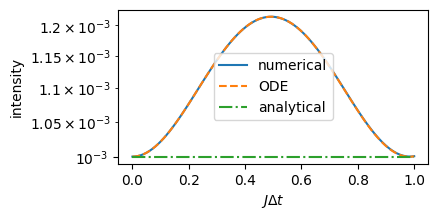

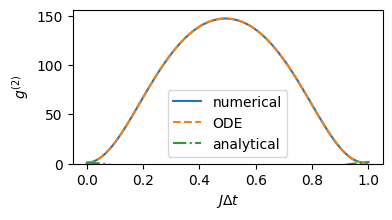

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))
plt.semilogy(tlist, n_BS_ts[:,1])
plt.semilogy(tlist, n_ODE, "--")
plt.semilogy(tlist, [na] * num_t, "-.")

plt.xlabel(r"$J\Delta t$")
plt.ylabel("intensity")
plt.legend(["numerical", "ODE", "analytical"])
plt.show()

plt.figure(figsize=(4,2))
plt.plot(tlist, g2_BS_ts[:,1])
plt.plot(tlist, g2_ODE, "--")
plt.plot(tlist, g2_an, "-.")

plt.xlabel(r"$J\Delta t$")
plt.ylabel("$g^{(2)}$")
plt.legend(["numerical", "ODE", "analytical"])
plt.ylim(bottom=np.maximum(np.min(g2_an), 0.))
plt.show()

# number distribution

Probability of signal: 0.009902885132023975
conditioned SP probability: 0.9997466434701132


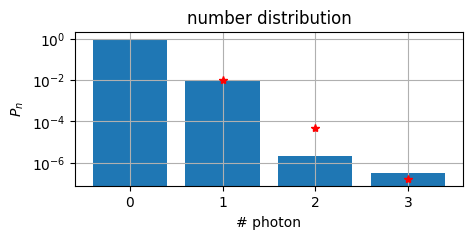

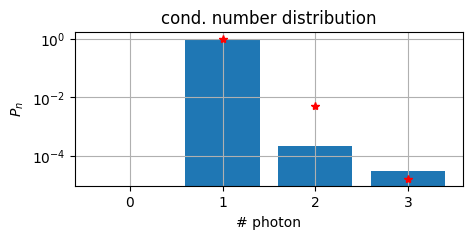

In [12]:
# find lowest g2 value
ind = np.argmin(g2_BS_ts[:,1])

# transform to S and AS modes -> application of pi/4 (50:50) BS
H_BS = H_BS_gen(np.pi/4.)
results = sesolve(H_BS, rho_ts[ind], [0, 1])

# compute number distributions
Pn = ptrace(results.states[-1], 1).diag()
Pn_coh = coherent_dm(N, alpha=np.sqrt(na)).diag()

# conditioned probabilities
Pn_cond = Pn.copy()
Pn_cond[0] = 0.
Pn_cond = Pn_cond / Pn_cond.sum()

Pn_coh_cond = Pn_coh
Pn_coh_cond[0] = 0.
Pn_coh_cond = Pn_coh_cond / Pn_coh_cond.sum()

# print some info
print(f"Probability of signal: {1. - Pn[0]}")
print(f"conditioned SP probability: {Pn_cond[1]}")

# the plot
N_max = 4
plt.figure(figsize=(5,2))
plt.bar(range(N_max), Pn[:N_max])
plt.plot(range(N_max), Pn_coh[:N_max], "r*")
plt.yscale('log')
plt.xlabel('# photon')
plt.ylabel(r"$P_n$")
plt.xticks(range(N_max))
plt.grid(True)
plt.title("number distribution")

plt.figure(figsize=(5,2))
plt.bar(range(N_max), Pn_cond[:N_max])
plt.plot(range(N_max), Pn_coh_cond[:N_max], "r*")
plt.yscale('log')
plt.xlabel('# photon')
plt.ylabel(r"$P_n$")
plt.xticks(range(N_max))
plt.grid(True)
plt.title("cond. number distribution")
plt.show()

In [63]:
Pn_coh_cond

array([0.00000000e+00, 9.95008333e-01, 4.97504167e-03, 1.65834722e-05,
       4.14586806e-08, 8.29173611e-11, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      